cell-1

In [1]:
import numpy as np
import pandas as pd
import os
import glob
import cv2
import statistics
from collections import deque

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    GlobalAveragePooling2D, RandomFlip, RandomRotation,
    RandomZoom, Rescaling
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow Version: {tf.__version__}")

2025-11-12 20:49:34.699679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762980575.146141      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762980575.251465      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow Version: 2.18.0


cell-2

In [2]:
DATA_PATH = "/kaggle/input/utkface-new/UTKFace/"


IMG_SIZE = 128 
CHANNELS = 1    
BATCH_SIZE = 64
EPOCHS = 50   
LEARNING_RATE = 1e-3

cell-3

In [3]:
def parse_utk_filename(filepath):
    """
    Parses the UTKFace filename to extract age, gender, and race.
    """
    try:
        basename = os.path.basename(filepath)
        parts = basename.split('_')
        age = int(parts[0])
        gender = int(parts[1])
        return filepath, age, gender
    except Exception as e:
        return None

image_files = glob.glob(os.path.join(DATA_PATH, "*.jpg"))
print(f"Found {len(image_files)} image files.")

data = [parse_utk_filename(f) for f in image_files]
data = [d for d in data if d is not None] 

df = pd.DataFrame(data, columns=['filepath', 'age', 'gender'])

df = df[(df['age'] > 0) & (df['age'] <= 100)]

print(f"Loaded and parsed {len(df)} valid images.")
print("\nDataFrame Head:")
print(df.head())

Found 23708 image files.
Loaded and parsed 23687 valid images.

DataFrame Head:
                                            filepath  age  gender
0  /kaggle/input/utkface-new/UTKFace/26_0_2_20170...   26       0
1  /kaggle/input/utkface-new/UTKFace/22_1_1_20170...   22       1
2  /kaggle/input/utkface-new/UTKFace/21_1_3_20170...   21       1
3  /kaggle/input/utkface-new/UTKFace/28_0_0_20170...   28       0
4  /kaggle/input/utkface-new/UTKFace/17_1_4_20170...   17       1


cell-4

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


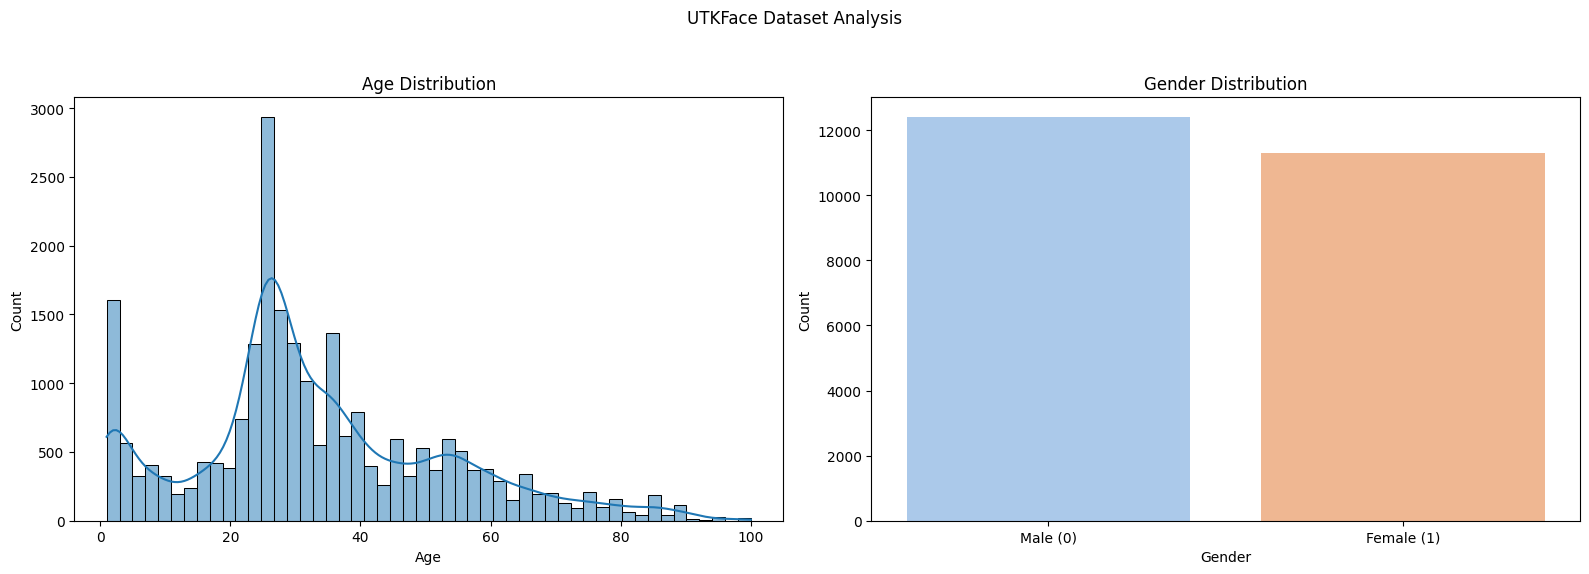

In [4]:
plt.figure(figsize=(16, 6))

# Plot Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=50, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Plot Gender Distribution
plt.subplot(1, 2, 2)
gender_counts = df['gender'].value_counts()
gender_counts.index = ['Male (0)' if i == 0 else 'Female (1)' for i in gender_counts.index]
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.suptitle('UTKFace Dataset Analysis')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

cell-5

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")

Training samples:   18949
Validation samples: 2369
Test samples:       2369


cell-6

In [6]:
data_augmentation = keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
], name="data_augmentation")

I0000 00:00:1762980601.616210      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762980601.617056      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


cell-7

In [7]:
def parse_image_and_labels(filepath, age, gender):
    """Loads image, resizes, converts to grayscale, and prepares labels."""

    img = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(img, channels=3) 

    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.rgb_to_grayscale(img)

    age = tf.cast(age, dtype=tf.float32)

    gender = tf.cast(gender, dtype=tf.float32)

    return img, {"output_gender": gender, "output_age": age}

def create_dataset(df, augment=False):
    """Creates a tf.data.Dataset from a DataFrame."""
    dataset = tf.data.Dataset.from_tensor_slices(
        (df['filepath'].values, df['age'].values, df['gender'].values)
    )

    dataset = dataset.map(
        parse_image_and_labels, 
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if augment:
        dataset = dataset.shuffle(buffer_size=len(df))
        
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(train_df, augment=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print("tf.data pipelines created (128x128 Grayscale).")


tf.data pipelines created (128x128 Grayscale).


cell-8

In [8]:
def build_custom_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    """
    Builds the custom multi-output CNN from the project proposal.
    """

    inputs = Input(shape=input_shape, name="input_layer")

    x = data_augmentation(inputs)
    x = Rescaling(1./255.)(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='valid', name="conv2d")(x)
    x = MaxPooling2D((2, 2), name="max_pooling2d")(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='valid', name="conv2d_1")(x)
    x = MaxPooling2D((2, 2), name="max_pooling2d_1")(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='valid', name="conv2d_2")(x)
    x = MaxPooling2D((2, 2), name="max_pooling2d_2")(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='valid', name="conv2d_3")(x)
    x = MaxPooling2D((2, 2), name="max_pooling2d_3")(x)

    x_shared = Flatten(name="flatten")(x) 

    gender_branch = Dense(256, activation="relu", name="dense")(x_shared)
    gender_branch = Dropout(0.5, name="dropout")(gender_branch) 
    output_gender = Dense(1, activation="sigmoid", name="output_gender")(gender_branch)

    age_branch = Dense(256, activation="relu", name="dense_1")(x_shared)
    age_branch = Dropout(0.5, name="dropout_1")(age_branch)
    output_age = Dense(1, activation="linear", name="output_age")(age_branch)

    model = Model(
        inputs=inputs, 
        outputs=[output_gender, output_age],
        name="Custom_CNN_Age_Gender"
    )
    
    return model

model = build_custom_cnn_model()

model.summary()


Model: "Custom_CNN_Age_Gender"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 256) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9216)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_gender       │ (None, 1)         │        257 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_age (Dense)  │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

cell-9

In [9]:
loss_dict = {
    "output_gender": "binary_crossentropy",
    "output_age": "mae"  
}

metrics_dict = {
    "output_gender": "accuracy",
    "output_age": "mae"
}

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=loss_dict,
    metrics=metrics_dict,
    loss_weights={"output_gender": 1.0, "output_age": 1.0}
)

print("Model compiled for training.")

Model compiled for training.


cell-10

In [10]:
checkpoint_cb = ModelCheckpoint(
    "best_model.keras", 
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=10,  
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,   
    patience=3,   
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [checkpoint_cb, early_stopping_cb, reduce_lr_cb]


cell-11

In [11]:
print("Starting training (custom model from scratch)...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

print("Training complete.")

Starting training (custom model from scratch)...
Epoch 1/50


I0000 00:00:1762980645.124114      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 18.0377 - output_age_loss: 17.3136 - output_age_mae: 17.3137 - output_gender_accuracy: 0.5133 - output_gender_loss: 0.7240
Epoch 1: val_loss improved from inf to 15.50168, saving model to best_model.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 60s 53ms/step - loss: 18.0328 - output_age_loss: 17.3087 - output_age_mae: 17.3089 - output_gender_accuracy: 0.5133 - output_gender_loss: 0.7239 - val_loss: 15.5017 - val_output_age_loss: 14.6282 - val_output_age_mae: 14.8094 - val_output_gender_accuracy: 0.5243 - val_output_gender_loss: 0.6929 - learning_rate: 0.0010
Epoch 2/50
296/297 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 15.4751 - output_age_loss: 14.7904 - output_age_mae: 14.7904 - output_gender_accuracy: 0.5359 - output_gender_loss: 0.6847
Epoch 2: val_loss improved from 15.50168 to 13.15445, saving model to best_model.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - loss: 15.4719 - output_age_loss: 14.7874 - output_age_mae: 14.7875 - output_gend

cell-12

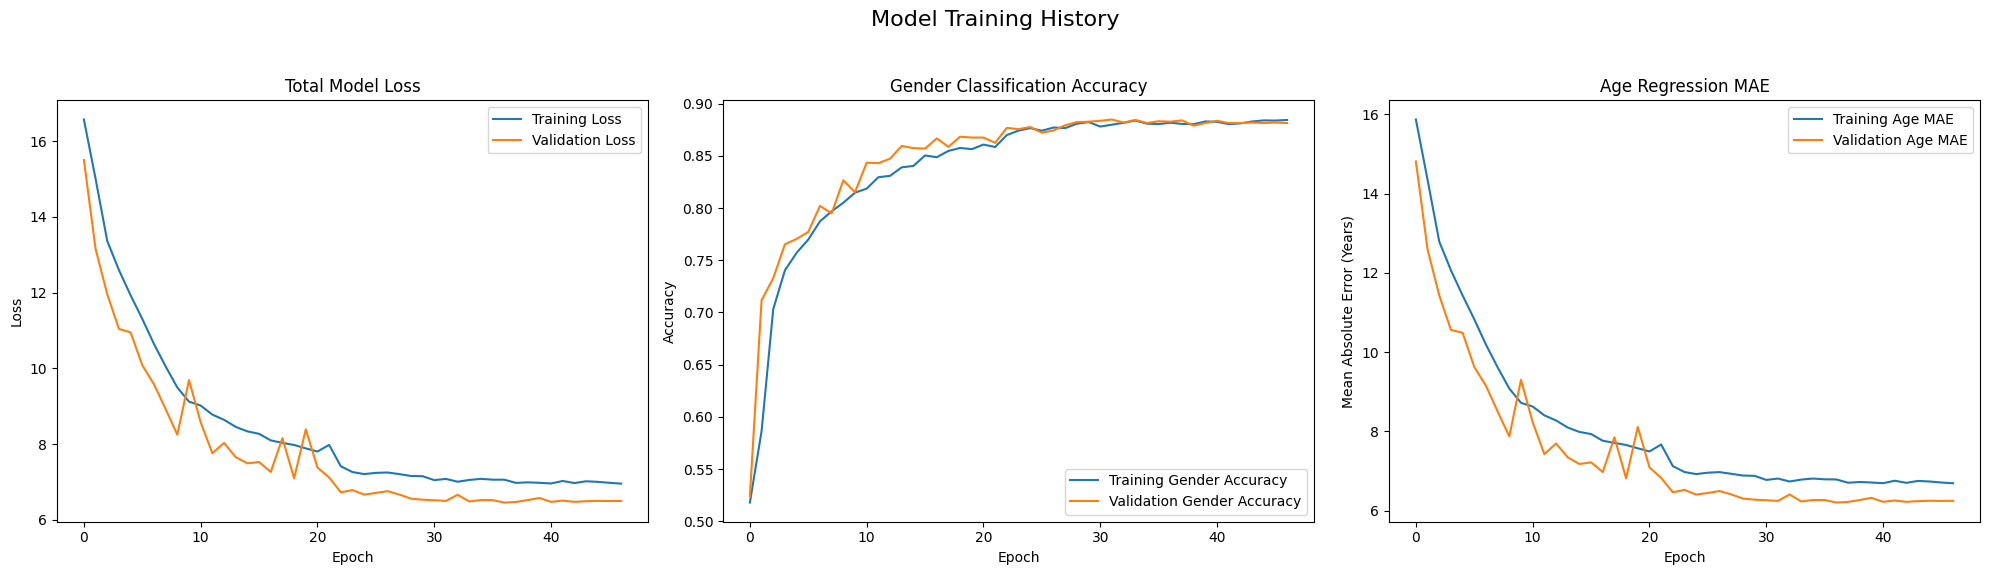

In [12]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(20, 6)) 

# 1. Total Loss
plt.subplot(1, 3, 1) 
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Total Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 2. Gender Accuracy
plt.subplot(1, 3, 2) 
plt.plot(history_df['output_gender_accuracy'], label='Training Gender Accuracy')
plt.plot(history_df['val_output_gender_accuracy'], label='Validation Gender Accuracy')
plt.title('Gender Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 3. Age MAE
plt.subplot(1, 3, 3) 
plt.plot(history_df['output_age_mae'], label='Training Age MAE')
plt.plot(history_df['val_output_age_mae'], label='Validation Age MAE')
plt.title('Age Regression MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (Years)')
plt.legend()

plt.suptitle('Model Training History', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


cell-13

In [13]:
print("Loading best model from checkpoint...")

model.load_weights("best_model.keras")

print("Evaluating model on test set...")

test_results = model.evaluate(test_ds, verbose=1)

print("\n--- Test Set Evaluation (Accessing by Index) ---")
print(f"Model Metrics Names: {model.metrics_names}")

try:

    total_loss  = test_results[0]
    gender_loss = test_results[1]
    age_loss    = test_results[2]
    gender_acc  = test_results[3]
    age_mae     = test_results[4]

    print(f"Total Loss:     {total_loss:.4f}")
    print(f"Gender Loss:    {gender_loss:.4f}")
    print(f"Age Loss (MAE): {age_loss:.4f}")
    print("---")
    print(f"Gender Accuracy: {gender_acc * 100:.2f}%")
    print(f"Age MAE:         {age_mae:.2f} years")

except IndexError:
    print("\nError: The test_results list did not have the expected number of items.")
    print("Please check model.metrics_names and the test_results list.")
    print(f"Test Results: {test_results}")
except Exception as e:
    print(f"\nAn error occurred while printing results: {e}")



Loading best model from checkpoint...
Evaluating model on test set...
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 6.6771 - output_age_loss: 6.4010 - output_age_mae: 6.4037 - output_gender_accuracy: 0.8832 - output_gender_loss: 0.2731

--- Test Set Evaluation (Accessing by Index) ---
Model Metrics Names: ['loss', 'compile_metrics', 'output_gender_loss', 'output_age_loss']
Total Loss:     6.5488
Gender Loss:    0.2648
Age Loss (MAE): 6.2239
---
Gender Accuracy: 627.78%
Age MAE:         0.88 years


cell-14

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 


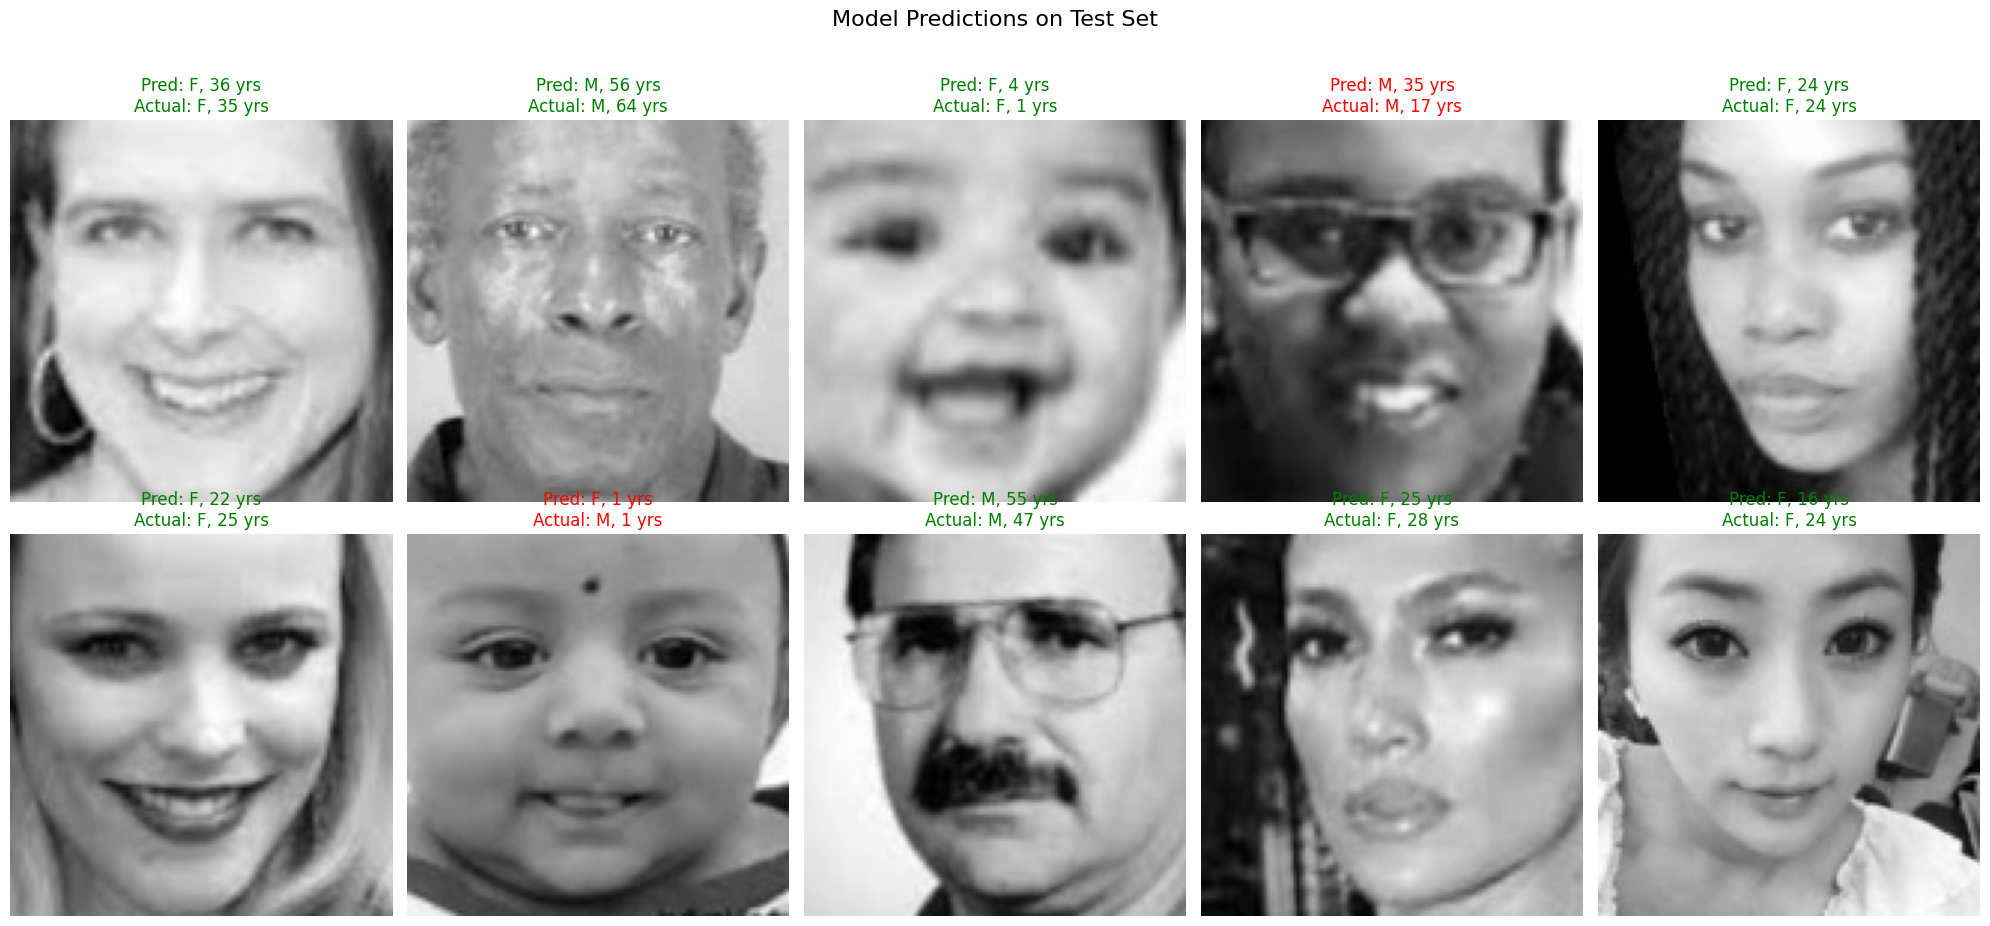

In [14]:
def show_predictions(model, test_dataset, num_images=10):
    """
    Takes a batch from the test dataset, predicts, and plots the results.
    """

    images, labels = next(iter(test_dataset))
    
    actual_genders = labels["output_gender"].numpy().squeeze()
    actual_ages = labels["output_age"].numpy().squeeze()

    gender_preds, age_preds = model.predict(images)

    gender_preds = (gender_preds.squeeze() > 0.5).astype(int)
    age_preds = age_preds.squeeze().astype(int)
    
    plt.figure(figsize=(20, 10))
    for i in range(num_images):
        if i >= len(actual_genders):
            break
            
        ax = plt.subplot(2, 5, i + 1)

        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.axis("off")
        
        pred_gender_str = "F" if gender_preds[i] == 1 else "M"
        actual_gender_str = "F" if actual_genders[i] == 1 else "M"
        
        title_color = 'green' if (pred_gender_str == actual_gender_str) and (abs(age_preds[i] - actual_ages[i]) < 10) else 'red'
        
        plt.title(
            f"Pred: {pred_gender_str}, {age_preds[i]} yrs\n"
            f"Actual: {actual_gender_str}, {int(actual_ages[i])} yrs",
            color=title_color
        )
    
    plt.suptitle("Model Predictions on Test Set", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Show some predictions
show_predictions(model, test_ds)

cell-15

In [15]:
FINAL_MODEL_NAME = "age_gender_custom_cnn_v1.keras"

try:
    os.rename("best_model.keras", FINAL_MODEL_NAME)
    print(f"Final model saved as '{FINAL_MODEL_NAME}'")
    print("This uses the modern .keras format and avoids .h5 warnings.")
except Exception as e:
    print(f"Error renaming model: {e}")
    print("Saving with model.save() as a fallback...")
    model.save(FINAL_MODEL_NAME) 


Final model saved as 'age_gender_custom_cnn_v1.keras'
This uses the modern .keras format and avoids .h5 warnings.


cell-16